# Posterior for SimBac simulation local recombination rate and mutation rate using SBI

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from Bio import Phylo
import seaborn as sns
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc, run_tarp, check_tarp
from sbi.analysis import sbc_rank_plot
from sbi.analysis import plot_tarp
import warnings
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform
from LeaveLengthOut_NN import LeaveLengthOut_NN

torch_device = "cpu"
warnings.filterwarnings("ignore", category=UserWarning)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load SimBac gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/final_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                 _______ 17
  ______________________________________________________________|
 |                                                              |     __ 19
 |                                                              |____|
 |                                                                   |__ 9
 |
 |                                                                  ____ 14
 |                                                                 |
_|                                                                 |    , 15
 |                                                      ___________|   _|
 |                                                     |           |  | , 5
 |                                                     |           |  | |
 |                                                     |           |__| | 24
 |                                                     |              |
 |                                    

In [3]:
drop_col = range(16, 32)

In [4]:
x_obs_df = pd.read_csv("../data/SimBac/rand_seg_summary.csv", header=None)
x_obs_np = x_obs_df.to_numpy()
x_obs_np = np.delete(x_obs_np, drop_col, axis=1)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([2000, 30]), torch.float32)

### Delete observations with no signal

In [5]:
no_signal_id = np.where(x_obs_np[:, 17] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((0,), array([], dtype=int64))

In [6]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((2000, 30), torch.Size([2000, 30]), torch.float32)

## Load simulation data

In [7]:
theta1 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x1.csv', delimiter=",")
nrow1 = x1.shape[0]

theta2 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x2.csv', delimiter=",")
nrow2 = x2.shape[0]

theta3 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x3.csv', delimiter=",")
nrow3 = x3.shape[0]

theta4 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x4.csv', delimiter=",")
nrow4 = x4.shape[0]

theta5 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x5.csv', delimiter=",")
nrow5 = x5.shape[0]

theta6 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta6.csv', delimiter=",")
x6 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x6.csv', delimiter=",")
nrow6 = x6.shape[0]

theta7 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta7.csv', delimiter=",")
x7 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x7.csv', delimiter=",")
nrow7 = x7.shape[0]

theta8 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta8.csv', delimiter=",")
x8 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x8.csv', delimiter=",")
nrow8 = x8.shape[0]

theta9 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta9.csv', delimiter=",")
x9 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x9.csv', delimiter=",")
nrow9 = x9.shape[0]

theta10 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/theta10.csv', delimiter=",")
x10 = np.loadtxt('../data/SimBac/ClonalOrigin_sim/x10.csv', delimiter=",")
nrow10 = x10.shape[0]

x = np.vstack([x1,  x2,  x3,  x4,  x5,  x6,  x7,  x8,  x9,  x10])
x = np.delete(x, drop_col, axis=1)
theta = np.vstack([theta1[:nrow1], theta2[:nrow2], theta3[:nrow3], theta4[:nrow4], theta5[:nrow5],
                   theta6[:nrow6], theta7[:nrow7], theta8[:nrow8], theta9[:nrow9], theta10[:nrow10]])

theta = theta[:50000, :]
x = x[:50000, :]

print(theta.shape, x.shape)

(50000, 3) (50000, 30)


In [8]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [9]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(30):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 17 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

In [10]:
len(ignore_indices), len(no_segregation), len(out_stats)

(0, 0, 0)

## NPE

### Create prior to pass range knowledge to NPE

In [11]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [12]:
embedding_net = LeaveLengthOut_NN(
    input_dim=30,
    num_hiddens=128,
    num_hidden_layers=1,
    num_outputs=2)
neural_posterior = posterior_nn(
    model="nsf",
    embedding_net=embedding_net,
    hidden_features=30,
    num_transforms=8,
    num_bins=5,
    z_score_theta="independent",
    z_score_x="independent"
)

In [13]:
seed = 100
num_posterior_samples=1000

inference = NPE_C(density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [14]:
# density_estimator = inference.append_simulations(theta, x).train(
#     max_num_epochs=500,
#     training_batch_size=100,
#     learning_rate=0.0001,
#     stop_after_epochs=20,
#     clip_max_norm=None
# )
# posterior = inference.build_posterior(density_estimator)

In [15]:
# fig, axes = plot_summary(
#     inference, 
#     tags=["training_loss", "validation_loss"], 
#     figsize=(8, 4)
# )
# plt.title("Training and Validation Loss")
# plt.show()

### Save the trained NPE

In [16]:
save_path = "../data/SimBac/trained_npe_posterior.pt"

# torch.save(
#     {
#         "posterior": posterior,
#         "sbi_version": sbi.__version__,
#         "seed": seed,
#         "learning_rate": 0.0001,
#         "max_num_epochs": 500,
#     },
#     save_path,
# )

In [17]:
checkpoint = torch.load(save_path, map_location="cpu")
posterior = checkpoint["posterior"]

C:\Users\u2008181\AppData\Local\Temp\ipykernel_24796\1569981112.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location="cpu")


In [18]:
save_path = "../data/SimBac/reconstruct_1/trained_npe_posterior.pt"
checkpoint = torch.load(save_path, map_location="cpu")
posterior1 = checkpoint["posterior"]

C:\Users\u2008181\AppData\Local\Temp\ipykernel_24796\4068282476.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location="cpu")


In [19]:
save_path = "../data/SimBac/reconstruct_2/trained_npe_posterior.pt"
checkpoint = torch.load(save_path, map_location="cpu")
posterior2 = checkpoint["posterior"]

C:\Users\u2008181\AppData\Local\Temp\ipykernel_24796\348128694.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location="cpu")


In [20]:
save_path = "../data/SimBac/reconstruct_3/trained_npe_posterior.pt"
checkpoint = torch.load(save_path, map_location="cpu")
posterior3 = checkpoint["posterior"]

C:\Users\u2008181\AppData\Local\Temp\ipykernel_24796\3563001243.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location="cpu")


### Plug in observations from real genes to get posterior

In [21]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(2000, 1000, 3)

In [22]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

In [23]:
theta_post_1 = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
for i in range(x_obs_torch.shape[0]):
    theta_post_torch = posterior1.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                         show_progress_bars=False, reject_outside_prior=False)
    theta_post_1[i, :, :] = theta_post_torch.cpu().detach().numpy()

In [24]:
theta_post_2 = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
for i in range(x_obs_torch.shape[0]):
    theta_post_torch = posterior2.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                         show_progress_bars=False, reject_outside_prior=False)
    theta_post_2[i, :, :] = theta_post_torch.cpu().detach().numpy()

In [25]:
theta_post_3 = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
for i in range(x_obs_torch.shape[0]):
    theta_post_torch = posterior3.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                         show_progress_bars=False, reject_outside_prior=False)
    theta_post_3[i, :, :] = theta_post_torch.cpu().detach().numpy()

### SBC

In [ ]:
y_sbc = np.full((x_obs_torch.shape[0], 3), np.nan)
y_sbc[:, 0] = 0.02
y_sbc[:, 1] = 0.05
y_sbc[:, 2] = x_obs_np[:, -1]
y_sbc

In [ ]:
sbc_results = []
np.random.seed(100)
torch.manual_seed(100)
num_posterior_samples = 1000
parameter_labels = ["rho", "theta", "L"]
y_obs_torch = torch.tensor(y_sbc, device=torch_device)
ranks, dap_samples = run_sbc(
    y_obs_torch,
    x_obs_torch,
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,
    reject_outside_prior=False
)

stats_sbc = check_sbc(
    ranks, 
    y_obs_torch, 
    dap_samples, 
    num_posterior_samples=num_posterior_samples
)

sbc_results.append({
    "ranks": ranks, 
    "stats": stats_sbc
})

In [ ]:
print(stats_sbc)

In [ ]:
print("Kolmogorov-Smirnov Test Results (SBC):")
print("-" * 45)

num_dimensions = ranks.shape[1] 

for dim in range(num_dimensions):
    normalized_ranks = ranks[:, dim] / num_posterior_samples
    ks_stat, p_value = stats.kstest(normalized_ranks, 'uniform')
    
    print(f"Parameter:        {parameter_labels[dim]}")
    print(f"KS Statistic (D): {ks_stat:.4f}")
    print(f"p-value:          {p_value:.4e}")

    if p_value < 0.05:
        print("Status: MISCALIBRATED (reject null)")
    else:
        print("Status: CALIBRATED (fail to reject null)")
    print("-" * 45)

In [ ]:
fig, ax = sbc_rank_plot(
    ranks, 
    num_posterior_samples, 
    plot_type="hist", 
    num_bins=10, 
    figsize=(14, 4.5), 
    parameter_labels=[r'for $\rho_s$', r'for $\theta_s$', 'for gene length']
)

fig.suptitle('NPE-C Posterior Calibration Check (SBC) for Observed Data from SimBac',
             fontsize=14, fontweight='bold', y=1.12)

global_handles, global_labels = [], []

for i, axis in enumerate(ax):
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.grid(axis='y', linestyle='--', alpha=0.4)
    
    for patch in axis.patches:
        if patch.get_facecolor()[:3] != (0.8, 0.8, 0.8): 
            patch.set_edgecolor('white')
            patch.set_linewidth(0.5)

    if i == 0:
        axis.set_ylabel('Count')

    legend = axis.get_legend()
    if legend is not None:
        global_handles = legend.legend_handles
        global_labels = [text.get_text() for text in legend.get_texts()]
        global_labels = ['Posterior Ranks' if l == 'rank set 1' else l for l in global_labels]
        legend.remove()

if global_handles and global_labels:
    fig.legend(global_handles, global_labels, loc='upper center', 
               bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('../output/simbac_sbc.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
np.mean(theta_post[:, :, 0], axis=1).shape

### TARP

In [ ]:
tarp_results = []
np.random.seed(100)
torch.manual_seed(100)
ecp, alpha = run_tarp(
    y_obs_torch,
    x_obs_torch,
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False
)

In [ ]:
stats_tarp = check_tarp(
    ecp,
    alpha
)

tarp_results.append({
    "ecp": ecp,
    "alpha": alpha,
    "stats": stats_tarp
})

In [ ]:
print(stats_tarp)

In [ ]:
fig, ax = plot_tarp(
    ecp, 
    alpha,
    title="TARP Plot"
)

plt.tight_layout()
plt.show()

### Posterior bias

In [28]:
import matplotlib.patches as mpatches

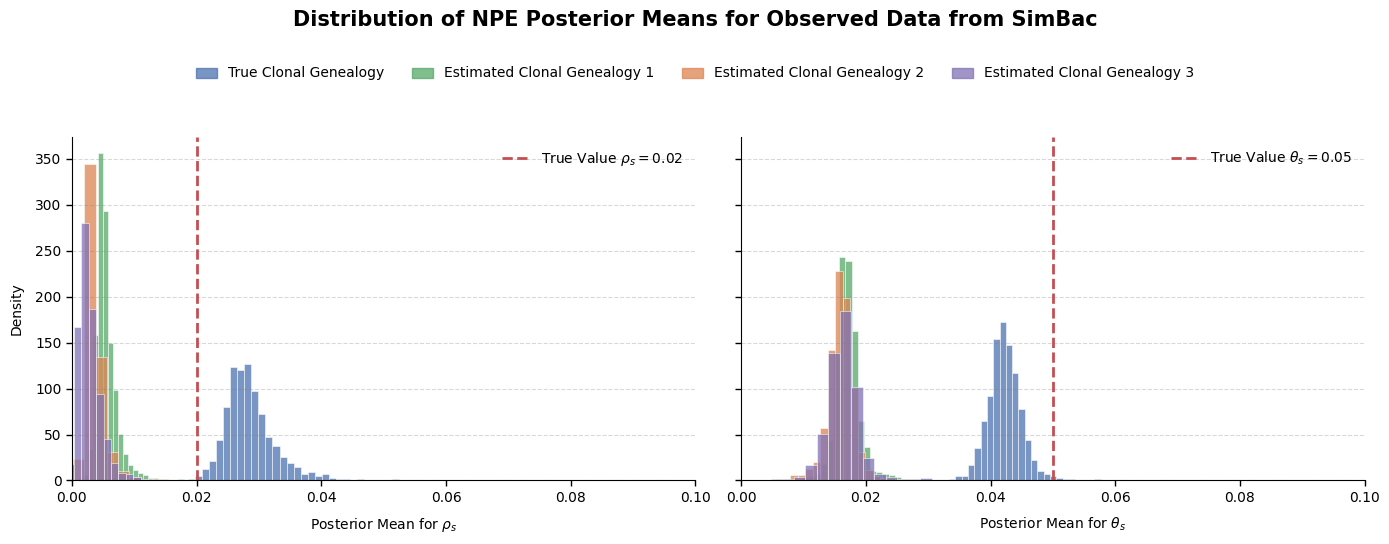

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
fig.suptitle('Distribution of NPE Posterior Means for Observed Data from SimBac', 
             fontsize=15, fontweight='bold', y=0.98)

rho_posterior_means = np.mean(theta_post[:, :, 0], axis=1)
theta_posterior_means = np.mean(theta_post[:, :, 1], axis=1)

rho_posterior_means_1 = np.mean(theta_post_1[:, :, 0], axis=1)
theta_posterior_means_1 = np.mean(theta_post_1[:, :, 1], axis=1)

rho_posterior_means_2 = np.mean(theta_post_2[:, :, 0], axis=1)
theta_posterior_means_2 = np.mean(theta_post_2[:, :, 1], axis=1)

rho_posterior_means_3 = np.mean(theta_post_3[:, :, 0], axis=1)
theta_posterior_means_3 = np.mean(theta_post_3[:, :, 1], axis=1)

axes[0].hist(rho_posterior_means, bins=30, density=True, alpha=0.75, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].hist(rho_posterior_means_1, bins=30, density=True, alpha=0.75, color='#55A868', edgecolor='white', linewidth=0.5)
axes[0].hist(rho_posterior_means_2, bins=30, density=True, alpha=0.75, color='#DD8452', edgecolor='white', linewidth=0.5)
axes[0].hist(rho_posterior_means_3, bins=30, density=True, alpha=0.75, color='#8172B3', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0.02, color='#C44E52', linestyle='--', linewidth=2, label=r'True Value $\rho_s = 0.02$')

axes[0].set_xlabel(r'Posterior Mean for $\rho_s$', labelpad=8)
axes[0].set_ylabel('Density', labelpad=8)
axes[0].set_xlim(0, 0.1)

axes[1].hist(theta_posterior_means, bins=30, density=True, alpha=0.75, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[1].hist(theta_posterior_means_1, bins=30, density=True, alpha=0.75, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].hist(theta_posterior_means_2, bins=30, density=True, alpha=0.75, color='#DD8452', edgecolor='white', linewidth=0.5)
axes[1].hist(theta_posterior_means_3, bins=30, density=True, alpha=0.75, color='#8172B3', edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0.05, color='#C44E52', linestyle='--', linewidth=2, label=r'True Value $\theta_s = 0.05$')

axes[1].set_xlabel(r'Posterior Mean for $\theta_s$', labelpad=8)
axes[1].set_xlim(0, 0.1)

legend_handles = [
    mpatches.Patch(color='#4C72B0', alpha=0.75, label='True Clonal Genealogy'),
    mpatches.Patch(color='#55A868', alpha=0.75, label='Estimated Clonal Genealogy 1'),
    mpatches.Patch(color='#DD8452', alpha=0.75, label='Estimated Clonal Genealogy 2'),
    mpatches.Patch(color='#8172B3', alpha=0.75, label='Estimated Clonal Genealogy 3')
]

fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.90),
           ncol=4, frameon=False, handlelength=1.5, columnspacing=2)

for ax in axes:
    ax.legend(loc='upper right', frameon=False) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=4, width=1)
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.savefig('../output/simbac_bias_estimated_tree.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()